# Setup & Load Data

tweets dataset - https://www.kaggle.com/datasets/kaushiksuresh147/bitcoin-tweets?select=Bitcoin_tweets_dataset_2.csv
sarcasm dataset - https://www.kaggle.com/datasets/danofer/sarcasm/data?select=train-balanced-sarcasm.csv

In [1]:
# Core
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# NLP
import re
import emoji
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from scipy.sparse import hstack, csr_matrix

# ML
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report


In [2]:
btc_df = pd.read_csv(
    "data/Bitcoin_tweets.csv",
    usecols=["date", "text"],   
    dtype={"text": "string"},
    parse_dates=["date"],
    low_memory=True
)
btc_df.head()


,date,text
0,2021-02-10 23:59:04,Blue Ridge Bank shares halted by NYSE after #b...
1,2021-02-10 23:58:48,"😎 Today, that's this #Thursday, we will do a ""..."
2,2021-02-10 23:54:48,"Guys evening, I have read this article about B..."
3,2021-02-10 23:54:33,$BTC A big chance in a billion! Price: \487264...
4,2021-02-10 23:54:06,This network is secured by 9 508 nodes as of t...


In [3]:
btc_df = btc_df[['date', 'text']].dropna()
btc_df.head()

,date,text
0,2021-02-10 23:59:04,Blue Ridge Bank shares halted by NYSE after #b...
1,2021-02-10 23:58:48,"😎 Today, that's this #Thursday, we will do a ""..."
2,2021-02-10 23:54:48,"Guys evening, I have read this article about B..."
3,2021-02-10 23:54:33,$BTC A big chance in a billion! Price: \487264...
4,2021-02-10 23:54:06,This network is secured by 9 508 nodes as of t...


In [4]:
sarc_df = pd.read_csv("data/train-balanced-sarcasm.csv")
sarc_df = sarc_df.rename(columns={"comment": "text"})

sarc_df = sarc_df[['label', 'text']].dropna()

sarc_df.head()


,label,text
0,0,NC and NH.
1,0,You do know west teams play against west teams...
2,0,"They were underdogs earlier today, but since G..."
3,0,"This meme isn't funny none of the ""new york ni..."
4,0,I could use one of those tools.


In [5]:
def clean_text(text):
    text = str(text)
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"#", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

sarc_df['text'] = sarc_df['text'].apply(clean_text)

# Training Sarcasm Model

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    sarc_df['text'],
    sarc_df['label'],
    test_size=0.2,
    random_state=42,
    stratify=sarc_df['label']
)


In [7]:
# Word-level
word_vec = TfidfVectorizer(
    max_features=30000,
    ngram_range=(1,3),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

# Character-level (captures tone, elongation, sarcasm patterns)
char_vec = TfidfVectorizer(
    analyzer='char',
    ngram_range=(3,5),
    max_features=20000
)

X_train_word = word_vec.fit_transform(X_train)
X_val_word = word_vec.transform(X_val)

X_train_char = char_vec.fit_transform(X_train)
X_val_char = char_vec.transform(X_val)

In [8]:
def cap_features(texts):
    features = []
    
    for text in texts:
        total_chars = len(text)
        upper_chars = sum(1 for c in text if c.isupper())
        upper_ratio = upper_chars / total_chars if total_chars > 0 else 0
        
        has_all_caps_word = any(
            word.isupper() and len(word) > 2 
            for word in text.split()
        )
        
        features.append([upper_ratio, int(has_all_caps_word)])
    
    return np.array(features)

X_train_caps = cap_features(X_train)
X_val_caps = cap_features(X_val)

# Convert to sparse
X_train_caps = csr_matrix(X_train_caps)
X_val_caps = csr_matrix(X_val_caps)

In [9]:
X_train_vec = hstack([X_train_word, X_train_char, X_train_caps])
X_val_vec = hstack([X_val_word, X_val_char, X_val_caps])

In [10]:
model = LogisticRegression(
    max_iter=3000,
    C=2.0,
    class_weight='balanced'
)

model.fit(X_train_vec, y_train)

LogisticRegression(C=2.0, class_weight='balanced', max_iter=3000)

In [11]:

pred = model.predict(X_val_vec)
print(classification_report(y_val, pred))


              precision    recall  f1-score   support

           0       0.72      0.76      0.74    101081
           1       0.75      0.71      0.73    101074

    accuracy                           0.73    202155
   macro avg       0.74      0.73      0.73    202155
weighted avg       0.74      0.73      0.73    202155



In [12]:
def sarcasm_probability(text):
    text = clean_text(text)
    
    word_part = word_vec.transform([text])
    char_part = char_vec.transform([text])
    caps_part = csr_matrix(cap_features([text]))
    
    combined = hstack([word_part, char_part, caps_part])
    
    prob = model.predict_proba(combined)[0][1]
    return prob

In [13]:
sample_texts = [
    "Bitcoin is doing AMAZING 😂😂",
    "Yeah right, BTC is totally stable",
    "Bitcoin price rising steadily",
    "BTC crashing hard today",
    "YEAHHH BITCOING IS SO GOOOOOOD"
]

for t in sample_texts:
    print(t)
    print("Sarcasm prob:", sarcasm_probability(t))
    print()


Bitcoin is doing AMAZING 😂😂
Sarcasm prob: 0.7637832720302764

Yeah right, BTC is totally stable
Sarcasm prob: 0.9943080208460428

Bitcoin price rising steadily
Sarcasm prob: 0.5045632095641677

BTC crashing hard today
Sarcasm prob: 0.5807462357981966

YEAHHH BITCOING IS SO GOOOOOOD
Sarcasm prob: 0.7822634833501683



# Making a sentiment analyser

In [14]:

analyzer = SentimentIntensityAnalyzer()

def extract_emojis(text):
    return ''.join(c for c in str(text) if c in emoji.EMOJI_DATA)

def remove_emojis(text):
    return ''.join(c for c in str(text) if c not in emoji.EMOJI_DATA)



In [15]:
emoji_sentiment = {
    # Bullish
    "🚀": 0.95, "📈": 0.85, "💰": 0.80, "💎": 0.75,
    "🤑": 0.80, "🔥": 0.70, "🐂": 0.85,
    "💪": 0.60, "🎉": 0.75, "🥳": 0.75,
    "⭐": 0.60, "🏆": 0.75, "👑": 0.70,
    "🪙": 0.70, "💵": 0.70, "💴": 0.65,
    "💯": 0.65, "🌕": 0.80, "🌟": 0.70,

    # Bearish
    "📉": -0.90, "🔻": -0.75, "🔴": -0.70,
    "🐻": -0.85, "💥": -0.70, "🛑": -0.75,
    "❌": -0.70, "💔": -0.75, "😭": -0.70,
    "😡": -0.75, "🤡": -0.65, "💀": -0.80,
    "😱": -0.65, "💣": -0.80, "🚨": -0.60,

    # Market-specific
    "🐳": 0.40, "🐋": 0.40,
    "⛏": 0.30, "⚡": 0.30,
    "📊": 0.20, "🔗": 0.20, "🌐": 0.20,

    # Sarcasm-sensitive
    "😂": -0.20, "🤣": -0.20,
    "🙄": -0.30, "😉": -0.10,
    "😏": -0.20, "🤔": 0.00,
    "👀": 0.10
}


In [16]:
def emoji_score(emojis):
    if not emojis:
        return 0
    
    scores = [emoji_sentiment.get(e, 0) for e in emojis]
    
    # repetition intensity boost
    intensity = 1 + 0.1 * (len(emojis) - 1)
    
    return np.mean(scores) * intensity


In [17]:
def baseline_vader(text):
    return analyzer.polarity_scores(str(text))['compound']

def es_vader(text, alpha=0.7, beta=0.3, lambda_sarc=0.8):
    
    text = str(text)
    
    emojis = extract_emojis(text)
    clean_text_only = remove_emojis(text)
    
    s_text = analyzer.polarity_scores(clean_text_only)['compound']
    s_emoji = emoji_score(emojis)
    
    s_base = alpha * s_text + beta * s_emoji
    
    s_prob = sarcasm_probability(text)
    
    # activate sarcasm only when strong
    adjusted_prob = max(0, s_prob - 0.6)
    
    s_final = s_base * (1 - lambda_sarc * adjusted_prob)
    
    return s_final


In [18]:
btc_df = btc_df.sample(n=150_000, random_state=42)

btc_df['vader_score'] = btc_df['text'].apply(baseline_vader)
btc_df['es_score'] = btc_df['text'].apply(es_vader)


In [19]:
btc_df.index = pd.to_datetime(btc_df.index, errors='coerce')
btc_df = btc_df[~btc_df.index.isna()]


In [20]:
print(type(btc_df.index))
print(btc_df.index[:5])
print(btc_df.dtypes)


<class 'pandas.core.indexes.datetimes.DatetimeIndex'>
DatetimeIndex(['1970-01-01 00:00:00.004300626',
               '1970-01-01 00:00:00.000703579',
               '1970-01-01 00:00:00.000250956',
               '1970-01-01 00:00:00.001053086',
               '1970-01-01 00:00:00.004293814'],
              dtype='datetime64[ns]', freq=None)
date                   object
text           string[python]
vader_score           float64
es_score              float64
dtype: object


In [21]:
one_min_vader = btc_df['vader_score'].resample("1T").mean()
one_min_es = btc_df['es_score'].resample("1T").mean()

five_min_vader = btc_df['vader_score'].resample("5T").mean()
five_min_es = btc_df['es_score'].resample("5T").mean()

fifteen_min_vader = btc_df['vader_score'].resample("15T").mean()
fifteen_min_es = btc_df['es_score'].resample("15T").mean()

one_hour_vader = btc_df['vader_score'].resample("1H").mean()
one_hour_es = btc_df['es_score'].resample("1H").mean()


D:\Test\ipykernel_21488\2135184056.py:1: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  one_min_vader = btc_df['vader_score'].resample("1T").mean()
D:\Test\ipykernel_21488\2135184056.py:2: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  one_min_es = btc_df['es_score'].resample("1T").mean()
D:\Test\ipykernel_21488\2135184056.py:4: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  five_min_vader = btc_df['vader_score'].resample("5T").mean()
D:\Test\ipykernel_21488\2135184056.py:5: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  five_min_es = btc_df['es_score'].resample("5T").mean()
D:\Test\ipykernel_21488\2135184056.py:7: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  fifteen_min_vader = btc_df['vader_score'].resample("15T

In [ ]:
btc_price = pd.read_csv("data/BTC_price.csv")
btc_price['date'] = pd.to_datetime(btc_price['date'])
btc_price.set_index('date', inplace=True)


In [23]:
def emoji_vader(text, alpha=0.7, beta=0.3):
    text = str(text)
    emojis = extract_emojis(text)
    clean_text_only = remove_emojis(text)

    s_text = analyzer.polarity_scores(clean_text_only)['compound']
    s_emoji = emoji_score(emojis)

    return alpha * s_text + beta * s_emoji


In [24]:
btc_df['emoji_vader_score'] = btc_df['text'].apply(emoji_vader)


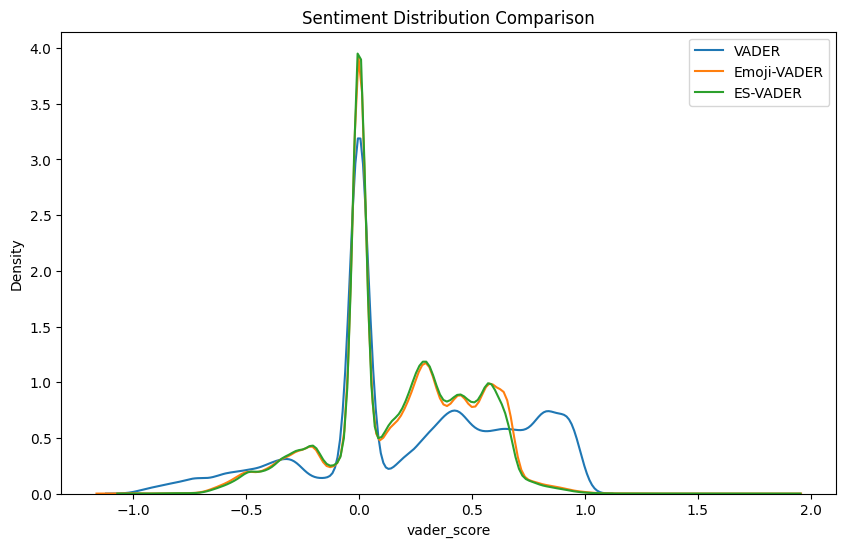

In [25]:


plt.figure(figsize=(10,6))

sns.kdeplot(btc_df['vader_score'], label='VADER')
sns.kdeplot(btc_df['emoji_vader_score'], label='Emoji-VADER')
sns.kdeplot(btc_df['es_score'], label='ES-VADER')

plt.title("Sentiment Distribution Comparison")
plt.legend()
plt.show()


In [26]:
btc_df['difference'] = btc_df['es_score'] - btc_df['vader_score']

btc_df.sort_values('difference', ascending=False)[['text','vader_score','es_score']].head(10)


,text,vader_score,es_score
1970-01-01 00:00:00.003136041,GOT ME SOME VOLT GOT ME SOME VOLT GOT ME SOME ...,-0.9701,1.618846
1970-01-01 00:00:00.000258030,@TolgaYl04814895 @shopping_io @Shibtoken #SHIB...,-0.9647,1.277780
1970-01-01 00:00:00.003523896,@JYaha48 @moon_guurl One of the best tweets ev...,-0.9897,1.119160
1970-01-01 00:00:00.012260485,🚀Join us on #GSX50🔥 Follow us https://t.co/69...,-0.9274,1.151690
1970-01-01 00:00:00.000711532,@Kodx_warrior @APompliano @kodxofficial 🔥💰🔥💰🔥💰...,-0.9729,1.049335
1970-01-01 00:00:00.000654974,@Kodx_warrior @whale_alert @kodxofficial 🔥💰🔥💰🔥...,-0.9729,1.049335
1970-01-01 00:00:00.000652734,@ALIHASHEMSEIF @Aboghzal4 🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥 Forget a...,-0.9893,1.022963
1970-01-01 00:00:00.000653792,@binance 🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥 Forget all the Tokens you...,-0.9893,1.022963
1970-01-01 00:00:00.001318989,$BORUTO 🚀🚀🚀🚀🚀 Beautiful Chart Today!!! Watch...,-0.9639,1.032642
1970-01-01 00:00:00.000810546,@Kodx_warrior @jack @MarkWarner @kodxofficial ...,-0.9903,0.981226


In [27]:
btc_df.sort_values('difference')[['text','vader_score','es_score']].head(10)


,text,vader_score,es_score
1970-01-01 00:00:00.002201837,#btc is getting royally fucked 😂😂😂😂😂😂😂😂😂😂😂😂😂,0.9839,-0.593790
1970-01-01 00:00:00.002066942,@Dennis_Porter_ I think the illegal activity i...,0.8122,-0.678350
1970-01-01 00:00:00.004079302,"❤💛💚💙 &gt; in this scam bull cycle, #Bitcoin b...",0.8327,-0.612010
1970-01-01 00:00:00.001239342,"INSANE, ASK NORMIES TOMORROW WHAT THEY THINK A...",0.9241,-0.506205
1970-01-01 00:00:00.000730464,"🧡💛💚💙 If #Bitcoin is digital gold, and Gold's m...",0.9186,-0.490210
1970-01-01 00:00:00.001552008,@BrendanBlumer is a poor man's @SBF_FTX #EOS...,0.8074,-0.598570
1970-01-01 00:00:00.003852981,Maybe this guy has an electrical problem at ho...,0.9943,-0.393489
1970-01-01 00:00:00.002242831,@iWantCoinNews It's building A. I can see 5th ...,0.9073,-0.465010
1970-01-01 00:00:00.004558408,@Tiagogreis @mendlowicz 🤣 #bitcoin forever. 🤣🤣...,0.9118,-0.452690
1970-01-01 00:00:00.004502206,#开云 #开云体育 #火狐体育 #世界杯 #卡塔尔世界杯 #足球 #竞彩 #电竞 #NBA ...,0.9393,-0.419580


In [28]:
emoji_tweets = btc_df[btc_df['text'].apply(lambda x: len(extract_emojis(x)) > 0)]


In [29]:
print("VADER avg (emoji tweets):", emoji_tweets['vader_score'].mean())
print("Emoji-VADER avg:", emoji_tweets['emoji_vader_score'].mean())
print("ES-VADER avg:", emoji_tweets['es_score'].mean())


VADER avg (emoji tweets): 0.25316312676611685
Emoji-VADER avg: 0.23944908848270638
ES-VADER avg: 0.23235213270480545


In [30]:
btc_df['sarcasm_prob'] = btc_df['text'].apply(sarcasm_probability)


In [31]:
sarcastic = btc_df[btc_df['sarcasm_prob'] > 0.75]

sarcastic[['text','vader_score','es_score','sarcasm_prob']].head(10)


,text,vader_score,es_score,sarcasm_prob
1970-01-01 00:00:00.000250956,"#bitcoin has no top, because #fiat has no bott...",-0.4199,-0.229728,0.873034
1970-01-01 00:00:00.003316201,@SnapFingersDAO @boyang_h @CassavaNetwork @Vib...,0.8625,0.507026,0.907067
1970-01-01 00:00:00.000196136,Strongest Movers #USDT 1 #Terra $luna 2 #Qu...,0.7845,0.472305,0.774917
1970-01-01 00:00:00.002483464,@altcryptocom #SHIBNOBI_DOJOSWAP is released! ...,0.8346,0.439332,0.910004
1970-01-01 00:00:00.003334449,"🚨 355 #BTC (10,541,325 USD) just transferred 🚨...",0.3612,0.047641,0.764088
1970-01-01 00:00:00.003420991,"This project has the ability to succeed, with ...",0.8979,0.549981,0.756216
1970-01-01 00:00:00.004328023,"Leading cryptocurrency Brn token, the future i...",-0.7351,0.207592,0.820279
1970-01-01 00:00:00.003270165,Yes all should accept #bitcoin as a #virtualas...,0.4106,0.226368,0.865519
1970-01-01 00:00:00.004445233,"@maxkeiser Oh, so when did #BTC hit that $220k...",-0.2960,-0.163157,0.865701
1970-01-01 00:00:00.003502479,SIGN UP HERE &gt;&gt; https://t.co/tbbulLuEyq ...,0.5574,0.334168,0.779444


In [32]:
def label_sentiment(score):
    if score > 0.05:
        return "Positive"
    elif score < -0.05:
        return "Negative"
    else:
        return "Neutral"

btc_df['vader_label'] = btc_df['vader_score'].apply(label_sentiment)
btc_df['es_label'] = btc_df['es_score'].apply(label_sentiment)


In [33]:
pd.crosstab(btc_df['vader_label'], btc_df['es_label'])


es_label,Negative,Neutral,Positive
vader_label,,,
Negative,19596,1118,2846
Neutral,1995,40638,6076
Positive,1153,2161,74417


In [34]:
from scipy.stats import ttest_rel

ttest_rel(btc_df['vader_score'], btc_df['es_score'])


TtestResult(statistic=95.81161417702207, pvalue=0.0, df=149999)

In [35]:
sample_50 = btc_df.sample(50, )
for i, row in sample_50.iterrows():
    print("="*80)
    print("Tweet:")
    print(row['text'])
    print("\nScores:")
    print(f"VADER       : {row['vader_score']:.4f} ({row['vader_label']})")
    print(f"Emoji-VADER : {row['emoji_vader_score']:.4f}")
    print(f"ES-VADER    : {row['es_score']:.4f} ({row['es_label']})")
    print(f"Sarcasm Prob: {row['sarcasm_prob']:.4f}")


Tweet:
2062.43 #BTC has been transfered to an unknown address 

          𝗦𝗲𝗻𝗱𝗲𝗿: bc1qahy22h9pzl20yg6fm3kc9rx9u8mllc49xr5j0x       
          Balance: 0.00 BTC

          𝗥𝗲𝗰𝗶𝗲𝘃𝗲𝗿: 38B3CoPjfXFfu8NG4qHbJyG2x62HQFwWNF       
          Balance: 2062.36 BTC

Scores:
VADER       : 0.0000 (Neutral)
Emoji-VADER : 0.0000
ES-VADER    : 0.0000 (Neutral)
Sarcasm Prob: 0.4117
Tweet:
@beamingkitty #ada is the primecoin.

#Btc has lost due to high production  cost and centralising. Furthermore, Bitcoin blocchain is pretty much useless. 
Maybe btc will gain some "gold standard".

#cardano on the other hand has it all. Usability,  traceability, decentralized, scalability.

Scores:
VADER       : 0.6908 (Positive)
Emoji-VADER : 0.4836
ES-VADER    : 0.4836 (Positive)
Sarcasm Prob: 0.4867
Tweet:
A live look at the bears trying to stop #Bitcoin bulls right now   https://t.co/IDdlnGlb8J

Scores:
VADER       : -0.2960 (Negative)
Emoji-VADER : -0.2072
ES-VADER    : -0.2072 (Negative)
Sarcasm Prob: 0.3845
Twee

In [36]:
emoji_sentiment_auto = {}

for em in emoji.EMOJI_DATA:
    description = emoji.EMOJI_DATA[em]['en']  # English description
    score = analyzer.polarity_scores(description)['compound']
    emoji_sentiment_auto[em] = score

In [37]:
print("🚀:", emoji_sentiment_auto["🚀"])
print("😭:", emoji_sentiment_auto["😭"])
print("💎:", emoji_sentiment_auto["💎"])
print("💀:", emoji_sentiment_auto["💀"])


🚀: 0.0
😭: 0.0
💎: 0.0
💀: 0.0


In [38]:
def emoji_score(emojis):
    if not emojis:
        return 0
    
    scores = [emoji_sentiment_auto.get(e, 0) for e in emojis]
    
    intensity = 1 + 0.1 * (len(emojis) - 1)
    
    return np.mean(scores) * intensity


In [39]:
emoji_sentiment_auto.update({
    "🚀": 0.9,
    "📈": 0.8,
    "📉": -0.8,
    "🐻": -0.7,
    "🐂": 0.7,
    "💎": 0.5
})


In [40]:
btc_df['emoji_vader_score'] = btc_df['text'].apply(emoji_vader)
btc_df['es_score'] = btc_df['text'].apply(es_vader)


In [41]:
for i, row in sample_50.iterrows():
    print("="*80)
    print("Tweet:")
    print(row['text'])
    print("\nScores:")
    print(f"VADER       : {row['vader_score']:.4f} ({row['vader_label']})")
    print(f"Emoji-VADER : {row['emoji_vader_score']:.4f}")
    print(f"ES-VADER    : {row['es_score']:.4f} ({row['es_label']})")
    print(f"Sarcasm Prob: {row['sarcasm_prob']:.4f}")

Tweet:
2062.43 #BTC has been transfered to an unknown address 

          𝗦𝗲𝗻𝗱𝗲𝗿: bc1qahy22h9pzl20yg6fm3kc9rx9u8mllc49xr5j0x       
          Balance: 0.00 BTC

          𝗥𝗲𝗰𝗶𝗲𝘃𝗲𝗿: 38B3CoPjfXFfu8NG4qHbJyG2x62HQFwWNF       
          Balance: 2062.36 BTC

Scores:
VADER       : 0.0000 (Neutral)
Emoji-VADER : 0.0000
ES-VADER    : 0.0000 (Neutral)
Sarcasm Prob: 0.4117
Tweet:
@beamingkitty #ada is the primecoin.

#Btc has lost due to high production  cost and centralising. Furthermore, Bitcoin blocchain is pretty much useless. 
Maybe btc will gain some "gold standard".

#cardano on the other hand has it all. Usability,  traceability, decentralized, scalability.

Scores:
VADER       : 0.6908 (Positive)
Emoji-VADER : 0.4836
ES-VADER    : 0.4836 (Positive)
Sarcasm Prob: 0.4867
Tweet:
A live look at the bears trying to stop #Bitcoin bulls right now   https://t.co/IDdlnGlb8J

Scores:
VADER       : -0.2960 (Negative)
Emoji-VADER : -0.2072
ES-VADER    : -0.2072 (Negative)
Sarcasm Prob: 0.3845
Twee

In [42]:
def extract_emojis(text):
    return [c for c in str(text) if c in emoji.EMOJI_DATA]

all_emojis = []

for text in btc_df['text']:
    all_emojis.extend(extract_emojis(text))

unique_emojis = sorted(set(all_emojis))

print(f"Total unique emojis found: {len(unique_emojis)}")
print(unique_emojis)

Total unique emojis found: 1114
['©', '®', '‼', '⁉', '™', 'ℹ', '↔', '↖', '↗', '↘', '↙', '↩', '↪', '⌚', '⌛', '⏏', '⏩', '⏪', '⏫', '⏬', '⏭', '⏰', '⏱', '⏲', '⏳', 'Ⓜ', '▪', '▫', '▶', '◀', '◽', '◾', '☀', '☁', '☂', '☃', '☄', '☎', '☑', '☔', '☕', '☘', '☝', '☠', '☢', '☣', '☦', '☪', '☮', '☯', '☸', '☹', '☺', '♀', '♂', '♈', '♉', '♋', '♍', '♎', '♒', '♓', '♟', '♠', '♣', '♥', '♦', '♨', '♻', '♾', '⚒', '⚓', '⚔', '⚕', '⚖', '⚙', '⚛', '⚜', '⚠', '⚡', '⚪', '⚫', '⚰', '⚱', '⚽', '⚾', '⛄', '⛅', '⛈', '⛎', '⛏', '⛑', '⛓', '⛔', '⛩', '⛰', '⛱', '⛳', '⛵', '⛷', '⛹', '⛺', '⛽', '✂', '✅', '✈', '✉', '✊', '✋', '✌', '✍', '✏', '✒', '✔', '✖', '✝', '✨', '✳', '✴', '❄', '❇', '❌', '❎', '❓', '❔', '❕', '❗', '❣', '❤', '➕', '➖', '➡', '⤴', '⤵', '⬅', '⬆', '⬇', '⬛', '⬜', '⭐', '⭕', '〰', '〽', '㊙', '🀄', '🃏', '🅰', '🅱', '🅾', '🅿', '🆎', '🆒', '🆓', '🆔', '🆕', '🆗', '🆘', '🆙', '🆚', '🈴', '🌀', '🌁', '🌂', '🌃', '🌄', '🌅', '🌆', '🌇', '🌈', '🌉', '🌊', '🌋', '🌌', '🌍', '🌎', '🌏', '🌐', '🌑', '🌒', '🌓', '🌔', '🌕', '🌖', '🌗', '🌘', '🌙', '🌚', '🌛', '🌜', '🌝', '🌞', '🌟', '🌠', '🌡

In [43]:
from collections import Counter

emoji_counts = Counter(all_emojis)

# Sort by frequency descending
sorted_emojis = emoji_counts.most_common()

print(f"Total unique emojis: {len(sorted_emojis)}\n")

for em, count in sorted_emojis:
    print(f"{em}  ->  {count}")


Total unique emojis: 1114

🚀  ->  19011
🔥  ->  10593
✅  ->  4184
🚨  ->  3662
💰  ->  3596
💎  ->  3347
👇  ->  3031
⚡  ->  2830
🔻  ->  2824
🔴  ->  2237
📈  ->  2152
🟢  ->  2077
❤  ->  2062
👉  ->  1876
💥  ->  1796
💯  ->  1790
👀  ->  1628
📣  ->  1558
👍  ->  1556
😂  ->  1487
🐳  ->  1465
🤑  ->  1449
📉  ->  1305
⛏  ->  1224
😍  ->  1194
🦍  ->  1166
➡  ->  1141
💪  ->  1110
🏻  ->  1034
🤣  ->  978
🐋  ->  958
🙌  ->  932
🎉  ->  917
🥳  ->  915
😎  ->  858
🙏  ->  844
🤔  ->  828
🤩  ->  799
⬇  ->  797
💸  ->  790
💵  ->  774
🛑  ->  748
💴  ->  724
📢  ->  675
⬆  ->  662
🥷  ->  654
‼  ->  629
⭐  ->  594
🤝  ->  571
👑  ->  554
♂  ->  513
🟩  ->  510
🏼  ->  509
💜  ->  507
👏  ->  480
🎁  ->  457
✨  ->  452
😉  ->  447
💚  ->  427
💕  ->  420
📅  ->  403
▶  ->  398
👌  ->  389
🪙  ->  381
✌  ->  376
🥰  ->  371
👈  ->  370
🎯  ->  367
⚠  ->  357
🐻  ->  356
👋  ->  344
😌  ->  343
♨  ->  343
🗣  ->  325
🔸  ->  317
💫  ->  294
🏝  ->  287
🤯  ->  282
🤷  ->  282
✔  ->  281
😊  ->  279
🏽  ->  279
🐶  ->  277
😁  ->  276
📋  ->  273
⏳  ->  

In [44]:
sample_5 = btc_df.sample(5, )
for i, row in sample_5.iterrows():
    print("="*80)
    print("Tweet:")
    print(row['text'])
    print("\nScores:")
    print(f"VADER       : {row['vader_score']:.4f} ({row['vader_label']})")
    print(f"Emoji-VADER : {row['emoji_vader_score']:.4f}")
    print(f"ES-VADER    : {row['es_score']:.4f} ({row['es_label']})")
    print(f"Sarcasm Prob: {row['sarcasm_prob']:.4f}")


Tweet:
The state now has 1,350 active locally-acquired #COVID19nsw cases, according to data from @CovidLiveAU.  That accounts for 91.5 percent of such #COVID19 cases nationwide.

#CovidIsNotOver.  If you haven't taken one, then please consider the universal benefits of a #CovidVaccine. https://t.co/HdwvhH7Q7J

Scores:
VADER       : 0.7650 (Positive)
Emoji-VADER : 0.5355
ES-VADER    : 0.5355 (Positive)
Sarcasm Prob: 0.2200
Tweet:
2013 - You missed #BTC
 2014 - You missed #DOGE
 2015 - You missed #XRP
 2016 - You missed #ETH
 2017 - You missed #ADA
 2018 - You missed #BNB
 2019 - You missed #LINK
 2020 - You missed #DOT
 2021 - You missed #SHIB 

🔥 In 2022, don't miss _____??

Scores:
VADER       : -0.9525 (Negative)
Emoji-VADER : -0.7603
ES-VADER    : -0.6780 (Negative)
Sarcasm Prob: 0.7354
Tweet:
@Floki_Meta A wonderful project that is here to stay. Wonderful team. Let's ride the crypto world 🚀🚀 🚀 

@stunnervictorr
@herunayakubu
@chukwujekwupro4
@IheakanduChukw1

#cryptocurrency #Airdr

In [45]:
row = btc_df.sample(n=1).iloc[0]

print("Tweet:")
print(row['text'])

print("\nScores:")
print(f"VADER       : {row['vader_score']:.4f} ({row['vader_label']})")
print(f"Emoji-VADER : {row['emoji_vader_score']:.4f}")
print(f"ES-VADER    : {row['es_score']:.4f} ({row['es_label']})")
print(f"Sarcasm Prob: {row['sarcasm_prob']:.4f}")


Tweet:
MoominHunter found #bitcoin in a Green vault at this location! Join me playing #coinhuntworld, It's awesome! https://t.co/18swfozfWK #cryptocurrency #405567 https://t.co/cgIHLkBGJ3

Scores:
VADER       : 0.8264 (Positive)
Emoji-VADER : 0.5785
ES-VADER    : 0.5785 (Positive)
Sarcasm Prob: 0.5306


In [46]:
row = btc_df.sample(n=1).iloc[0]

print("Tweet:")
print(row['text'])

print("\nScores:")
print(f"VADER       : {row['vader_score']:.4f} ({row['vader_label']})")
print(f"Emoji-VADER : {row['emoji_vader_score']:.4f}")
print(f"ES-VADER    : {row['es_score']:.4f} ({row['es_label']})")
print(f"Sarcasm Prob: {row['sarcasm_prob']:.4f}")


Tweet:
#Bitcoin  dominance  is doing something incredible 🤯

#Altcoins  were usually weak at the bottom of #BTC.
And now the index has fallen below 40% 🚀 https://t.co/0uVIJrozfD

Scores:
VADER       : -0.5574 (Negative)
Emoji-VADER : -0.2417
ES-VADER    : -0.2417 (Negative)
Sarcasm Prob: 0.4394
